In [4]:
from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator

In [5]:
#Load files
SP = Path("../data/synthetic_populations")

folder = SP / "full_specification"

import pandas as pd, numpy as np

rows = []

for spec in ["full_specification", "restricted_specification"]:
    folder = SP / spec
    for f in sorted(folder.glob("simulation_m*.csv")):
        d = pd.read_csv(f, usecols=["area", "weight", "has_any_care_needs"])
        d["needw"] = d["weight"] * d["has_any_care_needs"]

        g = d.groupby("area")[["weight", "needw"]].sum().reset_index()
        g.columns = ["area", "pop65", "need"]
        g["iteration"] = int(f.stem.split("_m")[-1])
        g["spec"] = spec.replace("_specification", "")

        rows.append(g)

est = pd.concat(rows, ignore_index=True)
est["prev"] = 1000 * est["need"] / est["pop65"]

print(est.shape)
print(est.head())

(6120, 6)
        area    pop65          need  iteration  spec        prev
0  E06000001  18233.0   7703.362906          1  full  422.495635
1  E06000002  24180.0  10113.895758          1  full  418.275259
2  E06000003  31747.0  12847.548193          1  full  404.685425
3  E06000004  37184.0  14583.724228          1  full  392.204288
4  E06000005  22040.0   8586.195224          1  full  389.573286


In [6]:
s = est.groupby(["spec", "area"])["prev"].agg(["mean", "std", "min", "max"]).reset_index()
s["range"] = s["max"] - s["min"]
s["cv_pct"] = 100 * s["std"] / s["mean"]

print(s.groupby("spec")[["mean", "std", "cv_pct", "range"]].describe().T)

spec                full  restricted
mean   count  153.000000  153.000000
       mean   384.965182  385.126597
       std     28.173909   28.743034
       min    297.301556  296.779949
       25%    364.612274  364.158055
       50%    382.041055  383.013526
       75%    404.989847  403.864575
       max    458.974823  468.014003
std    count  153.000000  153.000000
       mean     1.198925    0.896424
       std      0.670379    0.299025
       min      0.606705    0.456972
       25%      0.808466    0.677627
       50%      0.963419    0.800012
       75%      1.324061    1.074359
       max      4.905702    1.860583
cv_pct count  153.000000  153.000000
       mean     0.308595    0.231084
       std      0.162370    0.069051
       min      0.160449    0.109509
       25%      0.220287    0.187468
       50%      0.249565    0.210297
       75%      0.325045    0.268056
       max      1.148448    0.577023
range  count  153.000000  153.000000
       mean     4.725078    3.963687
 

In [7]:
w = s.pivot(index="area", columns="spec", values=["mean","std","cv_pct","range"])
w.columns = [f"{a}_{b}" for a,b in w.columns]
w = w.reset_index()
w["pop65"] = w["area"].map(est.groupby("area")["pop65"].mean())

names = pd.read_csv("../data/constraints/total.csv")
w = w.merge(names[["area_code","area_name"]], left_on="area", right_on="area_code", how="left")

print(w.nlargest(10, "cv_pct_full")[["area_name","mean_full","std_full","cv_pct_full","std_restricted","pop65"]].to_string(index=False))

print(w.nlargest(10, "cv_pct_restricted")[
    ["area_name","mean_restricted","std_restricted","cv_pct_restricted",
     "cv_pct_full","pop65"]].to_string(index=False))

     area_name  mean_full  std_full  cv_pct_full  std_restricted   pop65
        Newham 427.159086  4.905702     1.148448        1.473896 25166.0
         Brent 381.448575  3.903875     1.023434        0.827779 39555.0
     Leicester 419.331632  4.035246     0.962304        1.755188 43503.0
        Slough 403.198587  3.838280     0.951958        1.510756 15320.0
        Harrow 364.047504  3.050685     0.837991        0.703398 40179.0
       Hackney 418.407290  2.671942     0.638598        0.830747 20505.0
City of London 297.301556  1.892547     0.636575        1.712487  1206.0
     Redbridge 383.078040  2.329671     0.608145        0.679909 37932.0
      Hounslow 379.651891  2.238649     0.589658        0.747900 33950.0
 Tower Hamlets 458.974823  2.601480     0.566802        1.007823 17472.0
         area_name  mean_restricted  std_restricted  cv_pct_restricted  cv_pct_full   pop65
    City of London       296.779949        1.712487           0.577023     0.636575  1206.0
Kingston upon

In [8]:
nssec = pd.read_csv("../data/constraints/nssec.csv")

shares = ["nssec_managerial", "nssec_intermediate", "nssec_manual"]

p = w.merge(nssec[["area_code"] + shares], on="area_code", how="left")
p[shares] = p[shares].div(p[shares].sum(axis=1), axis=0)

p["range_pct_full"] = 100 * p["range_full"] / p["mean_full"]
p["range_pct_restricted"] = 100 * p["range_restricted"] / p["mean_restricted"]

p["mix"] = p["nssec_manual"] - p["nssec_managerial"]
p = p.sort_values("mix").reset_index(drop=True)
p["x"] = np.arange(len(p), dtype=float)

p["roll_full"] = p["range_pct_full"].rolling(25, center=True, min_periods=8).median()
p["roll_rest"] = p["range_pct_restricted"].rolling(25, center=True, min_periods=8).median()

top_full = p.nlargest(5, "range_pct_full").sort_values("range_pct_full").reset_index(drop=True)
top_rest = p.nlargest(5, "range_pct_restricted").sort_values("range_pct_restricted").reset_index(drop=True)

print(top_full[["area_name", "range_pct_full"]].to_string(index=False))
print(top_rest[["area_name", "range_pct_restricted"]].to_string(index=False))

area_name  range_pct_full
   Harrow        2.870650
    Brent        3.475968
Leicester        3.717715
   Slough        3.781033
   Newham        4.501270
         area_name  range_pct_restricted
    City of London              1.839443
         Leicester              1.903638
    Stoke-on-Trent              1.959955
          Sandwell              1.986730
Kingston upon Hull              2.000662



Vector PDF:
/home/juliana/Documents/PhD/paper_2/asc_need_sae/figures/fig_imputation_by_spec.pdf

Supporting data:
/home/juliana/Documents/PhD/paper_2/asc_need_sae/figures/fig_imputation_by_spec_data.csv


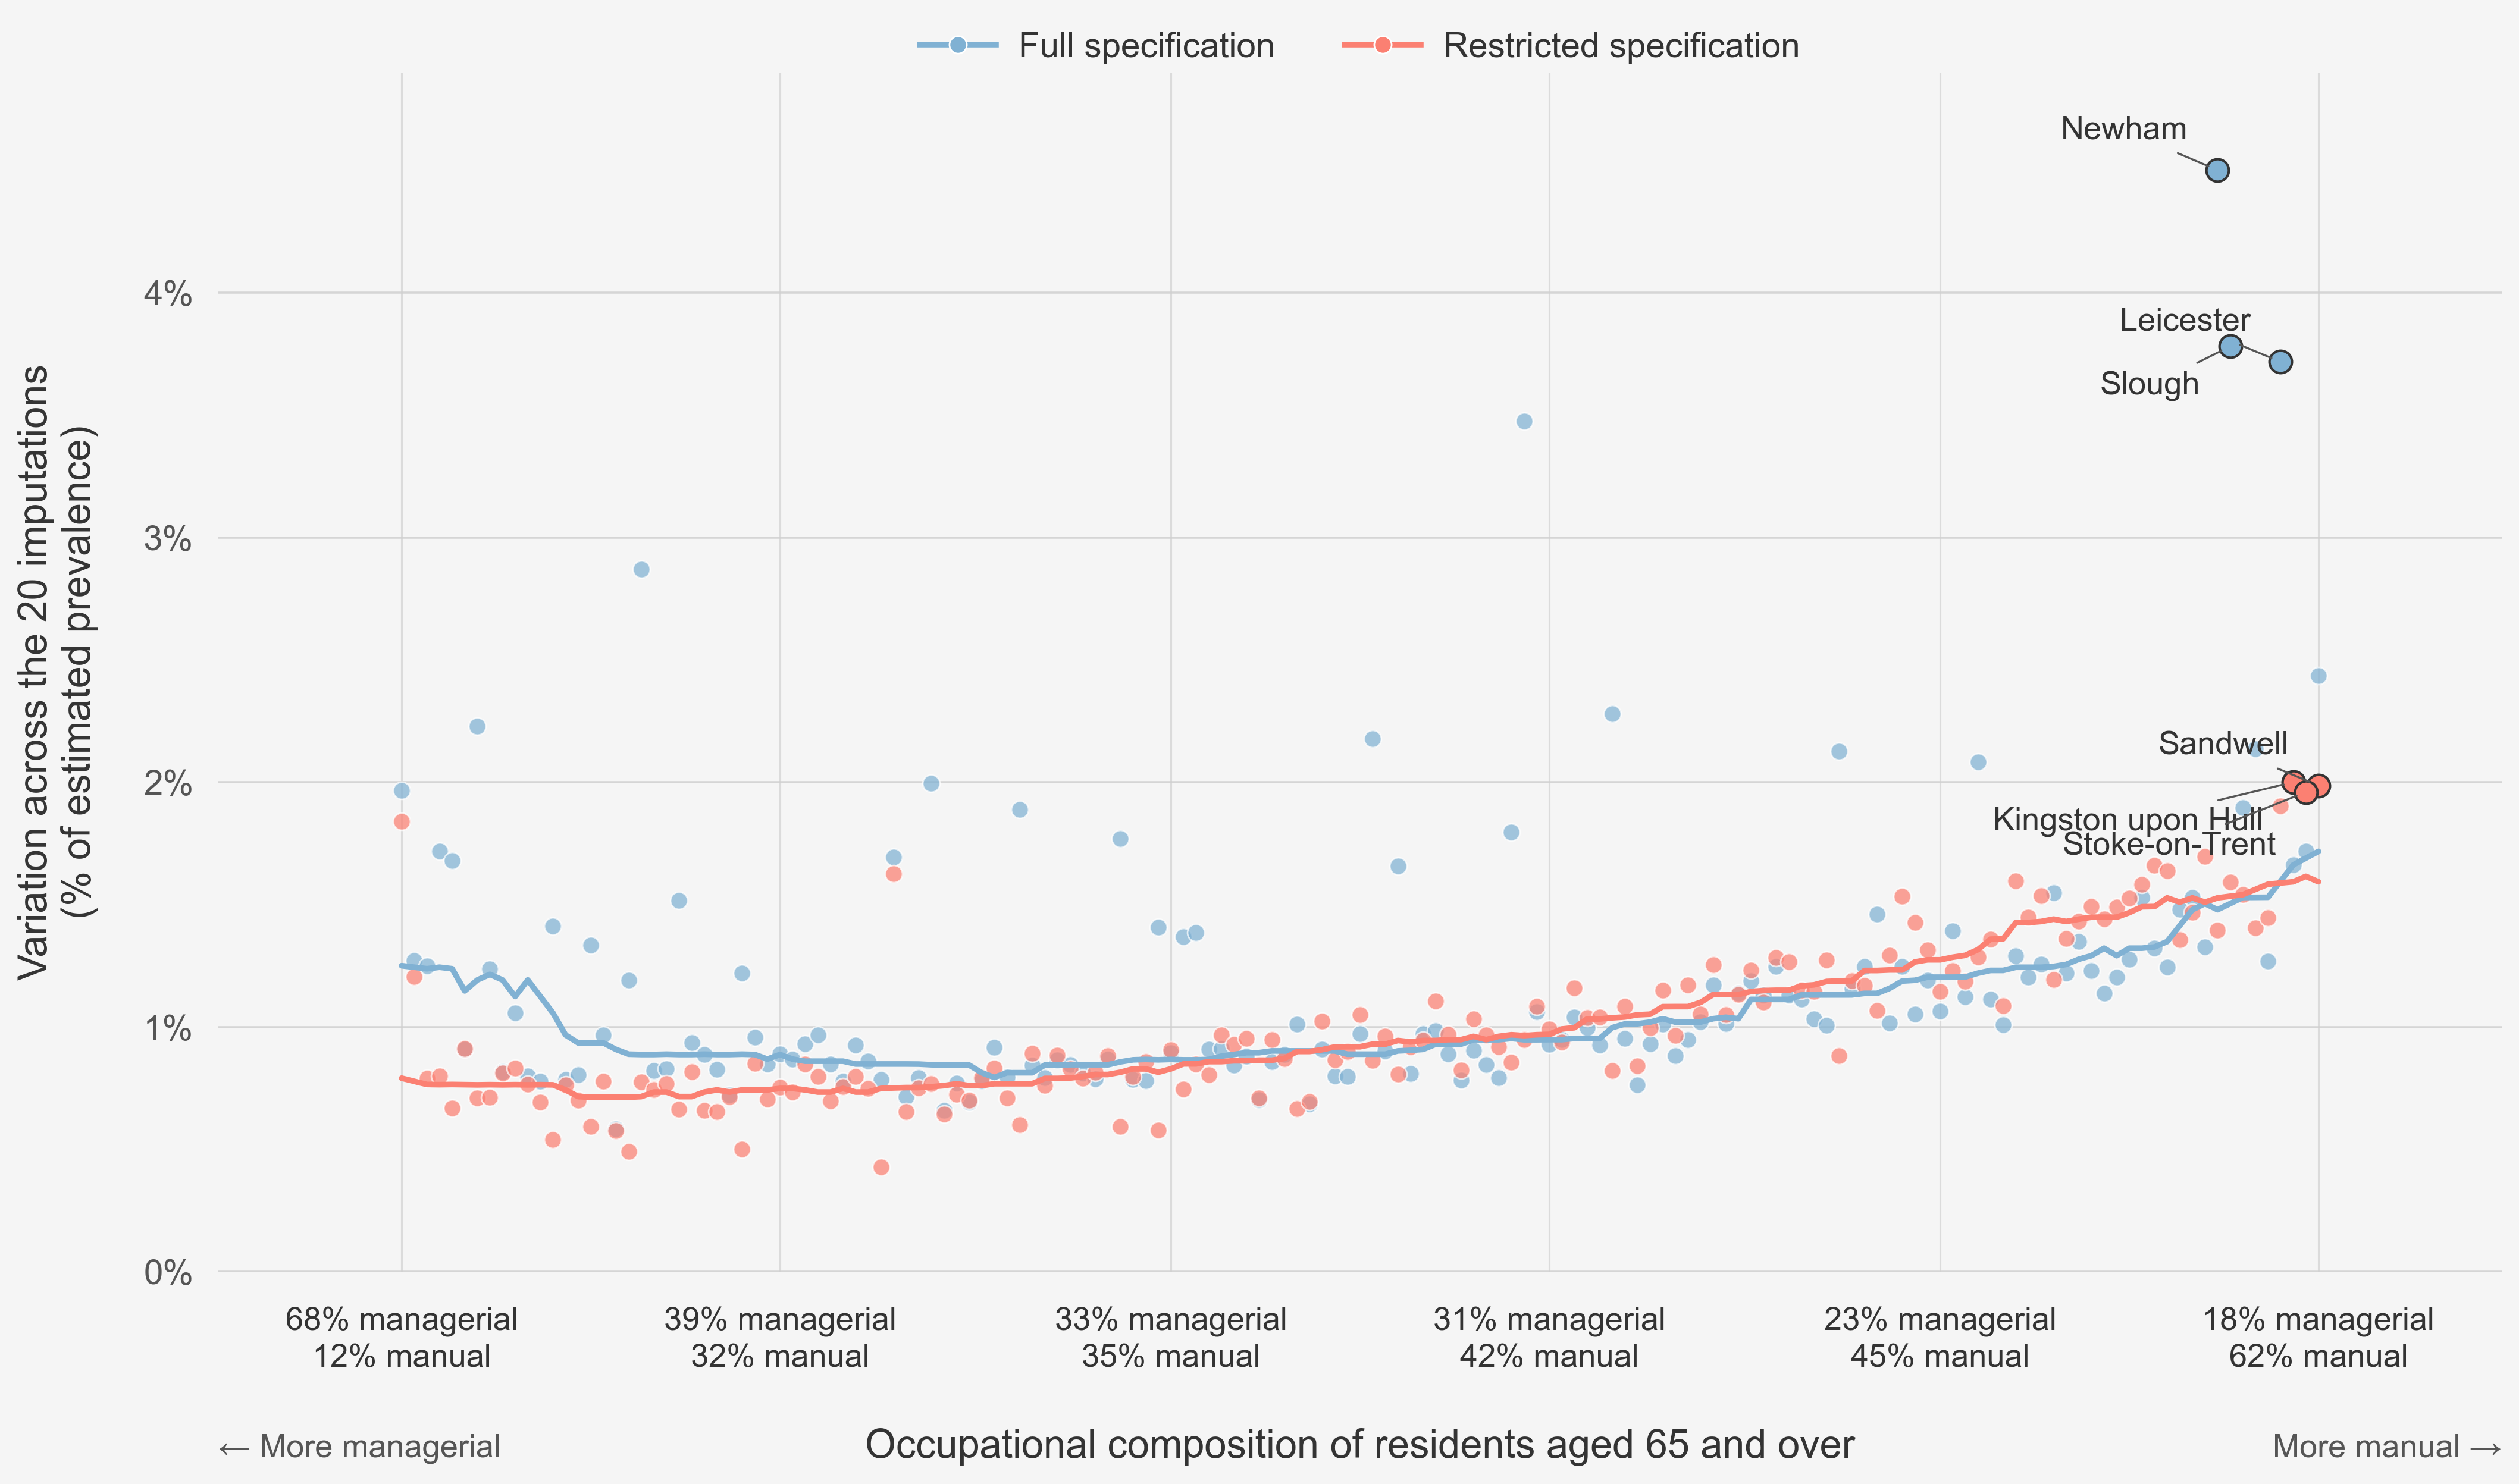

In [14]:
# Create figure

FONT = "Arial"
BACKGROUND, TEXT, SECONDARY_TEXT, GRID, WHITE = "#F5F5F5", "#333333", "#555555", "#D0D0D0", "#FFFFFF"

FULL_COLOUR = "#80B1D3"
RESTRICTED_COLOUR = "#FB8072"

GENERAL_FONT_SIZE, TICK_FONT_SIZE, X_TICK_FONT_SIZE = 15, 14, 13
AXIS_LABEL_FONT_SIZE, AREA_LABEL_FONT_SIZE = 16, 13
DIRECTION_FONT_SIZE, LEGEND_FONT_SIZE = 13, 14

mpl.rcParams.update({
    "font.family": FONT,
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.size": GENERAL_FONT_SIZE,
    "axes.labelsize": AXIS_LABEL_FONT_SIZE,
    "axes.labelcolor": TEXT,
    "xtick.labelsize": TICK_FONT_SIZE,
    "ytick.labelsize": TICK_FONT_SIZE,
    "xtick.color": SECONDARY_TEXT,
    "ytick.color": SECONDARY_TEXT,
    "legend.fontsize": LEGEND_FONT_SIZE,
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "figure.facecolor": BACKGROUND,
    "axes.facecolor": BACKGROUND,
    "savefig.facecolor": BACKGROUND,
    "savefig.transparent": False,
})

N_LABEL = 3
N_X_GROUPS = 6
ROLLING_WINDOW = 25
ROLLING_MIN_PERIODS = 8


required_columns = {"area_name", "nssec_managerial", "nssec_manual",
                    "range_pct_full", "range_pct_restricted"}

missing = required_columns.difference(p.columns)
if missing:
    raise KeyError(f"p is missing required columns: {sorted(missing)}")

p = p.copy()

for column in ["nssec_managerial", "nssec_manual",
               "range_pct_full", "range_pct_restricted"]:
    p[column] = pd.to_numeric(p[column], errors="coerce")

p = (p.replace([np.inf, -np.inf], np.nan)
       .dropna(subset=["area_name", "nssec_managerial", "nssec_manual",
                       "range_pct_full", "range_pct_restricted"])
       .copy())

p["manual_minus_managerial"] = p["nssec_manual"] - p["nssec_managerial"]
p = p.sort_values("manual_minus_managerial").reset_index(drop=True)

# Equally spaced rank positions, not literal percentage-point distance.
p["x"] = np.arange(len(p), dtype=float)
n = len(p)

p["roll_full"] = (p["range_pct_full"]
                  .rolling(window=ROLLING_WINDOW, center=True,
                           min_periods=ROLLING_MIN_PERIODS).median())

p["roll_rest"] = (p["range_pct_restricted"]
                  .rolling(window=ROLLING_WINDOW, center=True,
                           min_periods=ROLLING_MIN_PERIODS).median())

top_full = p.nlargest(N_LABEL, "range_pct_full").copy()
top_restricted = p.nlargest(N_LABEL, "range_pct_restricted").copy()


tick_indices = np.linspace(0, n - 1, N_X_GROUPS).round().astype(int)
tick_rows = p.iloc[tick_indices].copy()
tick_positions = tick_rows["x"].to_numpy()

tick_labels = [f"{100 * row.nssec_managerial:.0f}% managerial\n"
               f"{100 * row.nssec_manual:.0f}% manual"
               for row in tick_rows.itertuples()]

Y_MIN = 0
observed_max = float(max(p["range_pct_full"].max(),
                         p["range_pct_restricted"].max()))
Y_MAX = np.ceil(observed_max / 0.4) * 0.4 + 0.10


fig, ax = plt.subplots(figsize=(14.0, 8.2), dpi=300,
                       facecolor=BACKGROUND, layout="constrained")

fig.patch.set_facecolor(BACKGROUND)
ax.set_facecolor(BACKGROUND)

ax.scatter(p["x"], p["range_pct_full"], s=48,
           facecolor=FULL_COLOUR, edgecolor=WHITE,
           linewidth=0.65, alpha=0.72, zorder=3)

ax.scatter(p["x"], p["range_pct_restricted"], s=48,
           facecolor=RESTRICTED_COLOUR, edgecolor=WHITE,
           linewidth=0.65, alpha=0.72, zorder=3)

ax.plot(p["x"], p["roll_full"], color=FULL_COLOUR,
        linewidth=2.3, solid_capstyle="round", zorder=5)

ax.plot(p["x"], p["roll_rest"], color=RESTRICTED_COLOUR,
        linewidth=2.3, solid_capstyle="round", zorder=5)

ax.scatter(top_full["x"], top_full["range_pct_full"], s=82,
           facecolor=FULL_COLOUR, edgecolor=TEXT,
           linewidth=1.0, alpha=1.0, zorder=7)

ax.scatter(top_restricted["x"], top_restricted["range_pct_restricted"], s=82,
           facecolor=RESTRICTED_COLOUR, edgecolor=TEXT,
           linewidth=1.0, alpha=1.0, zorder=7)


def annotate_top_three(frame, value_column, *, series):

    frame = frame.sort_values(value_column, ascending=False)

    vertical_offsets = [10, -10, 10] if series == "full" else [-10, 10, -16]

    for j, (_, row) in enumerate(frame.iterrows()):

        x_fraction = row["x"] / max(n - 1, 1)

        if x_fraction > 0.60:
            x_offset, ha = -12, "right"
        else:
            x_offset, ha = 12, "left"

        y_offset = vertical_offsets[j]

        ax.annotate(row["area_name"],
                    xy=(row["x"], row[value_column]),
                    xytext=(x_offset, y_offset),
                    textcoords="offset points",
                    ha=ha,
                    va="bottom" if y_offset > 0 else "top",
                    fontsize=AREA_LABEL_FONT_SIZE,
                    color=TEXT,
                    arrowprops={"arrowstyle": "-", "color": SECONDARY_TEXT,
                                "linewidth": 0.8, "shrinkA": 3, "shrinkB": 4},
                    zorder=9)


annotate_top_three(top_full, "range_pct_full", series="full")
annotate_top_three(top_restricted, "range_pct_restricted", series="restricted")


ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, fontsize=X_TICK_FONT_SIZE,
                   color=TEXT, linespacing=1.30)

ax.tick_params(axis="x", length=0, pad=14)

ax.set_xlabel("Occupational composition of residents aged 65 and over",
              fontsize=AXIS_LABEL_FONT_SIZE, color=TEXT, labelpad=22)

ax.text(0.00, -0.135, "← More managerial", transform=ax.transAxes,
        ha="left", va="top", fontsize=DIRECTION_FONT_SIZE, color=SECONDARY_TEXT)

ax.text(1.00, -0.135, "More manual →", transform=ax.transAxes,
        ha="right", va="top", fontsize=DIRECTION_FONT_SIZE, color=SECONDARY_TEXT)

ax.yaxis.set_major_locator(MaxNLocator(nbins=5, min_n_ticks=4))
ax.yaxis.set_major_formatter(FuncFormatter(lambda value, position: f"{value:g}%"))

ax.tick_params(axis="y", length=0, pad=10, labelsize=TICK_FONT_SIZE)

ax.set_ylabel("Variation across the 20 imputations\n"
              "(% of estimated prevalence)",
              fontsize=AXIS_LABEL_FONT_SIZE, color=TEXT, labelpad=18)

ax.set_ylim(Y_MIN, Y_MAX)

horizontal_padding = n * 0.095
ax.set_xlim(-horizontal_padding, (n - 1) + horizontal_padding)

ax.grid(axis="y", color=GRID, linewidth=0.85, alpha=0.85, zorder=0)
ax.grid(axis="x", color=GRID, linewidth=0.75, alpha=0.70, zorder=0)
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_visible(False)

legend_handles = [
    Line2D([0], [0], marker="o", color=FULL_COLOUR, linewidth=2.3,
           markerfacecolor=FULL_COLOUR, markeredgecolor=WHITE,
           markeredgewidth=0.65, markersize=7, label="Full specification"),

    Line2D([0], [0], marker="o", color=RESTRICTED_COLOUR, linewidth=2.3,
           markerfacecolor=RESTRICTED_COLOUR, markeredgecolor=WHITE,
           markeredgewidth=0.65, markersize=7, label="Restricted specification"),
]

legend = ax.legend(handles=legend_handles, loc="upper center", frameon=False,
                   ncol=2, fontsize=LEGEND_FONT_SIZE, bbox_to_anchor=(0.5, 1.06),
                   handlelength=2.2, handletextpad=0.65, columnspacing=2.0)

for text in legend.get_texts():
    text.set_color(TEXT)


supporting_columns = [c for c in ["area_code", "area_name", "x",
                                  "nssec_managerial", "nssec_manual",
                                  "range_pct_full", "range_pct_restricted",
                                  "roll_full", "roll_rest"]
                      if c in p.columns]

supporting_table = p[supporting_columns].copy()
supporting_table["managerial_pct"] = 100 * supporting_table["nssec_managerial"]
supporting_table["manual_pct"] = 100 * supporting_table["nssec_manual"]

FIGURE_OUTPUT = Path("../figures/fig_imputation_by_spec.pdf")
TABLE_OUTPUT = Path("../figures/fig_imputation_by_spec_data.csv")

FIGURE_OUTPUT.parent.mkdir(parents=True, exist_ok=True)
TABLE_OUTPUT.parent.mkdir(parents=True, exist_ok=True)

fig.savefig(FIGURE_OUTPUT, format="pdf", bbox_inches="tight",
            facecolor=fig.get_facecolor())

supporting_table.to_csv(TABLE_OUTPUT, index=False)

print(f"\nVector PDF:\n{FIGURE_OUTPUT.resolve()}")
print(f"\nSupporting data:\n{TABLE_OUTPUT.resolve()}")

plt.show()